# UEQ
This notebook compares both versions (personalized vs. generic) of the system. 

### 1. Separate by version
As a first step, we import the raw scale data. The data is not filtered by version but by conversation. To obtain two data sets where all UEQ values for one version are in the same, set, we need to filter and sort by the group

In [1]:
# imports
import pandas as pd
import numpy as np
from typing import Literal
from scipy import stats
from statsmodels.stats.multitest import multipletests
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load datasets
ueq = pd.read_csv("./ueq.csv", encoding='UTF-8', delimiter=";")
participants = pd.read_csv("./participants.csv", encoding="UTF-8", delimiter=";")

# Merge only the 'ID' and 'group' columns from participants into ueq
ueq = pd.merge(ueq, participants[['ID', 'Group']], left_on='PID', right_on='ID', how='left')

ueq = ueq.drop(columns=['ID'])

ueq.rename(columns={
    'Group': 'group',
    'PID': 'pid'
}, inplace=True)

# move group next to PID
cols = list(ueq.columns)
cols.remove('group')             # Remove it from the end
pid_idx = cols.index('pid')      # Find where 'PID' is
cols.insert(pid_idx + 1, 'group') # Insert 'group' right after 'PID'

ueq = ueq[cols]

ueq.drop("Zeitstempel", axis=1, inplace=True)

ueq

,pid,group,1_1,1_2,1_3,1_4,1_5,1_6,1_7,1_8,...,2_17,2_18,2_19,2_20,2_21,2_22,2_23,2_24,2_25,2_26
0,1,control_first,7,7,3,1,1,7,7,4,...,4,1,1,7,1,7,1,1,1,7
1,2,experiment_first,7,3,3,2,1,7,7,6,...,3,1,1,7,3,7,1,2,1,7
2,3,experiment_first,7,7,3,2,2,5,6,5,...,3,2,2,6,2,6,2,2,1,5
3,4,control_first,6,4,3,2,1,6,6,3,...,2,2,3,5,3,7,2,3,1,5
4,5,experiment_first,6,6,2,1,1,5,5,6,...,2,2,2,5,2,6,4,2,1,2
5,6,control_first,5,5,3,3,2,6,6,4,...,1,3,5,3,5,2,5,5,7,6
6,7,experiment_first,6,6,2,2,2,6,7,7,...,2,2,2,5,4,6,3,3,1,6
7,8,experiment_first,7,7,1,3,1,6,7,3,...,1,1,1,7,2,7,1,1,1,4
8,9,control_first,7,5,3,2,1,6,6,6,...,4,3,1,6,2,7,5,4,2,4
9,10,control_first,5,7,3,2,1,5,5,7,...,4,1,2,5,4,6,4,2,1,5


In [3]:
# Now we transform the data so that we get 40 rows. Each row is one ueq form. Also we add the variant. 
ueq_melted = pd.melt(
    ueq, 
    id_vars=['pid', 'group'], 
    var_name='raw_item', 
    value_name='score'
)

# 2. Split the 'raw_item' column into 'iteration' and 'item_number'
# e.g., "1_2" becomes iteration=1, item_number=2
ueq_melted[['iteration', 'item_number']] = ueq_melted['raw_item'].str.split('_', expand=True)
ueq_melted['iteration'] = ueq_melted['iteration'].astype(int)
ueq_melted['item_number'] = ueq_melted['item_number'].astype(int)

# 3. Determine the variant (experiment vs control) based on group and iteration
conditions = [
    (ueq_melted['group'] == 'experiment_first') & (ueq_melted['iteration'] == 1),
    (ueq_melted['group'] == 'experiment_first') & (ueq_melted['iteration'] == 2),
    (ueq_melted['group'] == 'control_first') & (ueq_melted['iteration'] == 1),
    (ueq_melted['group'] == 'control_first') & (ueq_melted['iteration'] == 2)
]
choices = ['experiment', 'control', 'control', 'experiment']

ueq_melted['variant'] = np.select(conditions, choices, default="unknown")

# 4. Pivot the items back into columns so you have one row per participant per iteration
ueq_final = ueq_melted.pivot(
    index=['pid', 'group', 'iteration', 'variant'], 
    columns='item_number', 
    values='score'
).reset_index()

# Optional: Clean up column naming dust from the pivot
ueq_final.columns.name = None

ueq_final

,pid,group,iteration,variant,1,2,3,4,5,6,...,17,18,19,20,21,22,23,24,25,26
0,1,control_first,1,control,7,7,3,1,1,7,...,4,1,1,6,1,7,1,1,1,7
1,1,control_first,2,experiment,7,7,1,2,1,7,...,4,1,1,7,1,7,1,1,1,7
2,2,experiment_first,1,experiment,7,3,3,2,1,7,...,1,1,1,6,3,7,5,3,1,7
3,2,experiment_first,2,control,6,3,3,1,1,7,...,3,1,1,7,3,7,1,2,1,7
4,3,experiment_first,1,experiment,7,7,3,2,2,5,...,3,2,2,6,2,6,1,2,1,6
5,3,experiment_first,2,control,6,5,2,2,2,6,...,3,2,2,6,2,6,2,2,1,5
6,4,control_first,1,control,6,4,3,2,1,6,...,2,1,3,5,3,5,3,4,3,2
7,4,control_first,2,experiment,5,5,4,3,3,5,...,2,2,3,5,3,7,2,3,1,5
8,5,experiment_first,1,experiment,6,6,2,1,1,5,...,1,1,1,6,1,6,3,3,1,5
9,5,experiment_first,2,control,5,5,2,3,1,6,...,2,2,2,5,2,6,4,2,1,2


In [34]:
# export data to analyze in the UEQ Data Analysis tool
ueq_final.to_csv("./ueq_transformed.csv", index=False, sep=';', encoding='utf-8')

In [4]:
# We used the official Data Analysis tool of the UEQ authors to nromalize the data and calculate the values for the 6 dimensions.
# Now we need to extract the dimension values for each participants and both conditions
df_control = pd.read_excel("./UEQ_Compare_Products_Version14.xlsx", sheet_name="DT1", skiprows=2)
df_experiment = pd.read_excel("./UEQ_Compare_Products_Version14.xlsx", sheet_name="DT2", skiprows=2)

# the dimension names and the list with the respective items
dimension_items = {
    "Attractiveness": [1, 12, 14, 16, 24, 25], 
    "Perspicuity": [2, 4, 13, 21], 
    "Efficiency": [9, 20, 22, 23], 
    "Dependability": [8, 11, 17, 19], 
    "Stimulation": [5, 6, 7, 18], 
    "Novelty": [3, 10, 15, 26]
}

# make sure that we have no duplicate values in the nested array 
def are_all_values_unique(nested_data):
    """
    Checks if all elements in a nested structure (like a list of lists 
    or dict_values) are unique.
    """
    # Create a generator to yield all elements
    all_elements = (item for sublist in nested_data for item in sublist)
    
    # Track items we've seen
    seen = set()
    
    for item in all_elements:
        if item in seen:
            return False  # Found a duplicate, stop immediately
        seen.add(item)
        
    return True

print("All items are unique, no duplicates exist: ", are_all_values_unique(dimension_items.values()))

# select all columns we need for the data analysis 
all_columns = ["PID"] + list(dimension_items.keys()) + \
        sorted(list(item for sublist in dimension_items.values() for item in sublist))

def preprocess_data(df, variant: Literal["control", "experiment"]):
    """
    Returns the preprocessed df with all required columns for a specific variant.
    """
    filtered_df = df[all_columns]

    # for the subsequent steps, we lowercase the column names
    filtered_df.columns = [col.lower() if isinstance(col, str) else col for col in filtered_df.columns]

    # finally, merge the variant and group that are stored in the final ueq df so we can 
    # check for carry-over effects
    filtered_df = filtered_df.merge(
        ueq_final[ueq_final["variant"] == variant][["pid", "group", "variant"]], 
        how="left", 
        on="pid"
    )

    return filtered_df.sort_values("pid").set_index("pid")

df_control = preprocess_data(df_control, "control")
df_experiment = preprocess_data(df_experiment, "experiment")

assert(
    df_control.index == df_experiment.index
).all(), "Abbruch: pid's stimmen nicht überein"

All items are unique, no duplicates exist:  True


In [5]:
# 1. Reliability test 
alpha_results = []

# make sure that the columns are string or int
def get_cols(df, item_list):
    return [str(x) if str(x) in df.columns else x for x in item_list]

for dim, items in dimension_items.items(): 

    # turn dimension names to lowercase
    dim = dim.lower()

    # get only the column names for the items of one dimension at a time
    cols_ctrl = get_cols(df_control, items)
    cols_exp = get_cols(df_experiment, items)

    # caluclate cronbachs alpha for the dimensions
    a_ctrl, _ = pg.cronbach_alpha(data=df_control[cols_ctrl])
    a_exp, _ = pg.cronbach_alpha(data=df_experiment[cols_exp])

    alpha_results.append(
        {
            "dimension": dim,
            "alpha_control": round(a_ctrl, 3),
            "alpha_experiment": round(a_exp, 3),
            "status_control": (
                "Good"
                if a_ctrl >= 0.7
                else ("Acceptable" if a_ctrl >= 0.6 else "CRITICAL")
            ),
            "status_experiment": (
                "Good"
                if a_exp >= 0.7
                else ("Acceptable" if a_exp >= 0.6 else "CRITICAL")
            ),
        }
    )

df_alphas = pd.DataFrame(alpha_results)
df_alphas


,dimension,alpha_control,alpha_experiment,status_control,status_experiment
0,attractiveness,0.651,0.908,Acceptable,Good
1,perspicuity,0.840,0.416,Good,CRITICAL
2,efficiency,0.584,0.762,CRITICAL,Good
3,dependability,0.297,-0.241,CRITICAL,CRITICAL
4,stimulation,0.651,0.783,Acceptable,Good
5,novelty,0.784,0.776,Good,Good


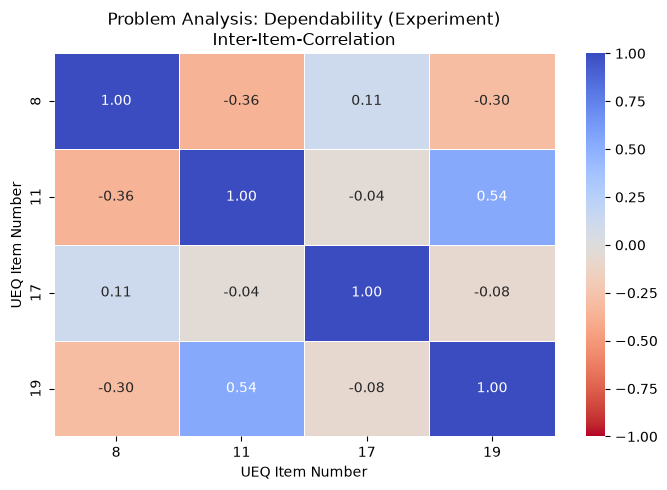


=== DIAGNOSIS TABLE FOR DEPENDABILITY (Experiment) ===
Current total alpha: -0.241
--------------------------------------------------
If item 8 is deleted -> New alpha: 0.239 (Remaining-item-r: -0.19)
If item 11 is deleted -> New alpha: -0.307 (Remaining-item-r: 0.04)
If item 17 is deleted -> New alpha: -0.459 (Remaining-item-r: -0.00)
If item 19 is deleted -> New alpha: -0.197 (Remaining-item-r: 0.05)


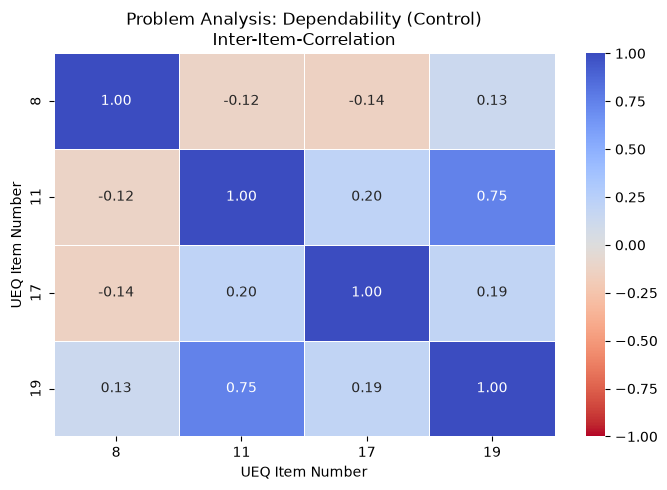


=== DIAGNOSIS TABLE FOR DEPENDABILITY (Control) ===
Current total alpha: 0.297
--------------------------------------------------
If item 8 is deleted -> New alpha: 0.589 (Remaining-item-r: -0.04)
If item 11 is deleted -> New alpha: 0.086 (Remaining-item-r: 0.28)
If item 17 is deleted -> New alpha: 0.361 (Remaining-item-r: 0.08)
If item 19 is deleted -> New alpha: -0.154 (Remaining-item-r: 0.36)


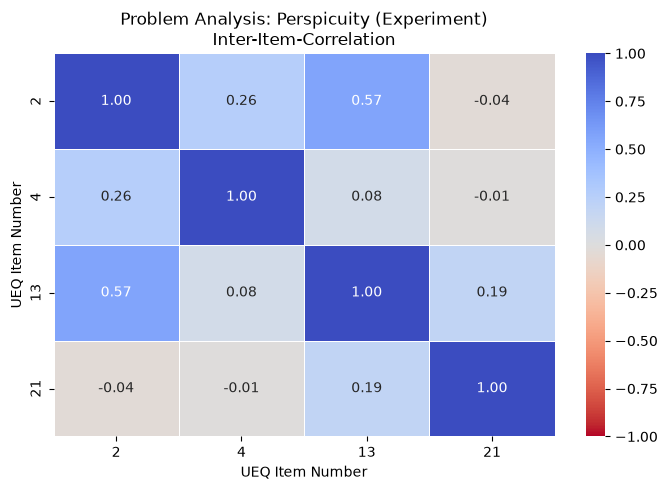


=== DIAGNOSIS TABLE FOR PERSPICUITY (Experiment) ===
Current total alpha: 0.416
--------------------------------------------------
If item 2 is deleted -> New alpha: 0.219 (Remaining-item-r: 0.26)
If item 4 is deleted -> New alpha: 0.428 (Remaining-item-r: 0.11)
If item 13 is deleted -> New alpha: 0.138 (Remaining-item-r: 0.28)
If item 21 is deleted -> New alpha: 0.567 (Remaining-item-r: 0.05)


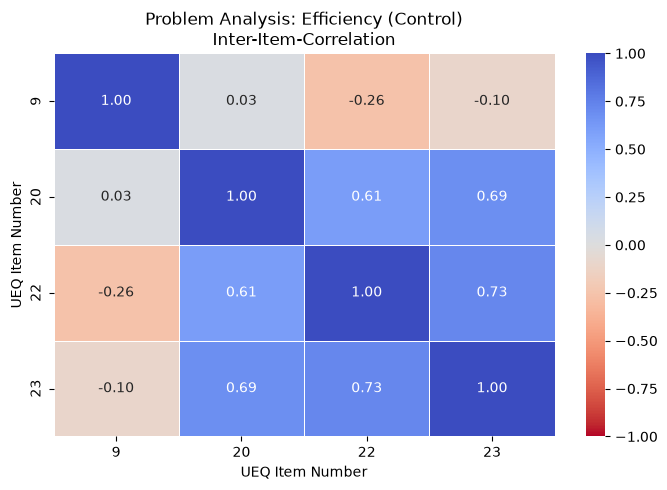


=== DIAGNOSIS TABLE FOR EFFICIENCY (Control) ===
Current total alpha: 0.584
--------------------------------------------------
If item 9 is deleted -> New alpha: 0.854 (Remaining-item-r: -0.11)
If item 20 is deleted -> New alpha: 0.273 (Remaining-item-r: 0.44)
If item 22 is deleted -> New alpha: 0.401 (Remaining-item-r: 0.36)
If item 23 is deleted -> New alpha: 0.261 (Remaining-item-r: 0.44)


In [6]:
def diagnose_dimension(df, item_list, dim_name, version_name):
    """Generiert eine Heatmap und berechnet die 'Alpha-if-item-deleted' Metriken"""
    # 1. Sicherstellen, dass Spalten korrekt matchen
    cols = [str(x) if str(x) in df.columns else x for x in item_list]
    sub_df = df[cols].copy()

    # 2. Plot aufbauen
    plt.figure(figsize=(7, 5))
    # Wir nutzen eine divergierende Farbpalette. Blau = Positiv, Rot = Negativ
    sns.heatmap(
        sub_df.corr(),
        annot=True,
        cmap="coolwarm_r",
        vmin=-1,
        vmax=1,
        fmt=".2f",
        linewidths=0.5,
    )
    plt.title(f"Problem Analysis: {dim_name} ({version_name})\nInter-Item-Correlation")
    plt.xlabel("UEQ Item Number")
    plt.ylabel("UEQ Item Number")
    plt.tight_layout()
    plt.show()

    # 3. Statistischer Check: Was passiert, wenn wir ein Item löschen?
    print(f"\n=== DIAGNOSIS TABLE FOR {dim_name.upper()} ({version_name}) ===")
    print(f"Current total alpha: {pg.cronbach_alpha(data=sub_df)[0]:.3f}")
    print("-" * 50)

    for item in cols:
        # Datensatz ohne das aktuelle Item
        reduced_df = sub_df.drop(columns=[item])
        alpha_dropped, _ = pg.cronbach_alpha(data=reduced_df)

        # Mittlere Korrelation des Items zu den anderen berechnen
        item_corr = sub_df.corr()[item].drop(item).mean()

        print(
            f"If item {item} is deleted -> New alpha: {alpha_dropped:.3f} (Remaining-item-r: {item_corr:.2f})"
        )


# =====================================================================
# STARTE DIE DIAGNOSE
# =====================================================================

# Untersuchung 1: Das negative Alpha bei Dependability (Experiment-Daten)
diagnose_dimension(
    df_experiment, dimension_items["Dependability"], "Dependability", "Experiment"
)

# Untersuchung 2: Das katastrophale Alpha bei Dependability (Control-Daten)
diagnose_dimension(df_control, dimension_items["Dependability"], "Dependability", "Control")

# Untersuchung 3: Der Einbruch bei Perspicuity (Experiment-Daten)
diagnose_dimension(
    df_experiment, dimension_items["Perspicuity"], "Perspicuity", "Experiment"
)

diagnose_dimension(
    df_control, dimension_items["Efficiency"], "Efficiency", "Control"
)

In [8]:
# Why: Different versions of the 'pingouin' package randomly rename their output columns.
# These two functions safely grab the p-value and Cohen's d, no matter what the column is called today.
def safe_p(df_res):
    print(df_res)
    for col in ["p-val", "p-value", "p", "P-val", "pvalue"]:
        if col in df_res.columns:
            return df_res[col].values[0]
    return np.nan


def safe_d(df_res):
    print(df_res)
    for col in ["cohen-d", "d", "cohens_d", "effect-size"]:
        if col in df_res.columns:
            return df_res[col].values[0]
    return np.nan

# helper to get the raw values for
def get_clean_scalar(val):
    # 1. If it's a Pandas Series or DataFrame, pull out the raw inner array
    if isinstance(val, (pd.Series, pd.DataFrame)):
        val = val.values

    # 2. Keep drilling down into the first element as long as it's still a list or array
    while hasattr(val, "__len__") and not isinstance(val, str):
        val = val[0]

    # 3. If it's a special Numpy float, strip it down to a standard Python float
    if hasattr(val, "item"):
        val = val.item()

    return float(val)


# =====================================================================
# MAIN STATISTICAL ANALYSIS (Using original, uncleaned UEQ scores)
# =====================================================================

# Step 0: Extract the exact names of your two counterbalancing groups
# Why: We need to know who tested which version first to check for order bias.
# .strip().lower() cleans up accidental typos in your Excel (like " Control_first ").
order_series = df_control["group"].astype(str).str.strip().str.lower()
order_groups = order_series.unique()

print(f"Detected counterbalancing groups: {order_groups}\n")

main_results = []

# Why: The UEQ questionnaire measures 6 completely independent UX qualities.
# We must run our pipeline strictly separate for each dimension, never lumped together.
for dim in dimension_items.keys():
    # Ensure dimension name is safely lowercase
    dim = dim.lower()

    # Step 1: Grab the 20 scores for the Experiment and Control version
    # Why: To isolate the paired data for the current UX dimension.
    s_exp = df_experiment[dim]
    s_ctrl = df_control[dim]

    # Step 2: Calculate the personal UX gain for each participant
    # Why: Within-subjects designs care about how much *individual* people changed their rating.
    # A positive number means this specific user liked the Experiment version better.
    diffs = s_exp - s_ctrl

    # Step 3: Shapiro-Wilk Test on the differences
    # Why: To check if our data follows a normal "bell curve" (a strict rule for running a T-test).
    _, p_shap = stats.shapiro(diffs)

    # Step 4: Paired T-Test
    # Why: This is our main test to see if the score difference between the versions is real or just random luck.
    ttest_res = pg.ttest(s_exp, s_ctrl, paired=True)
    p_ttest = float(ttest_res["p_val"].iloc[0])
    d_ttest = float(ttest_res["cohen_d"].iloc[0])

    # Step 5: Wilcoxon Signed-Rank Test
    # Why: This is our "safety backup" test just in case the Shapiro test says our data is not normal.
    wilc_res = pg.wilcoxon(s_exp, s_ctrl)
    p_wilc = float(wilc_res["p_val"].iloc[0])

    # Step 6: Carry-Over / Order Effect Check
    # Why: We check if Group A (saw Control first) gave different ratings than Group B (saw Experiment first).
    # If this p-value is > 0.05, it proves our counterbalancing worked and nobody was biased by the order.
    if len(order_groups) == 2:
        diffs_g1 = diffs[order_series == order_groups[0]]
        diffs_g2 = diffs[order_series == order_groups[1]]

        carry_res = pg.ttest(diffs_g1, diffs_g2, paired=False)
        p_carry = float(carry_res["p_val"].iloc[0])
    else:
        p_carry = np.nan

    # Step 7: Save everything in a clean dictionary row
    # Why: So we can convert the raw loop data into a structured Pandas table in the next step.
    main_results.append(
        {
            "Dimension": dim,
            "Mean_Control (SD)": f"{s_ctrl.mean():.2f} ({s_ctrl.std():.2f})",
            "Mean_Experiment (SD)": f"{s_exp.mean():.2f} ({s_exp.std():.2f})",
            "Mean_Diff": round(diffs.mean(), 2),
            "Shapiro_p": round(p_shap, 3),
            "t_stat": round(float(ttest_res["T"].iloc[0]), 2),  # FIXED: float + iloc[0]
            "t_p_raw": p_ttest,
            "Cohen_dz": round(d_ttest, 2),
            "Wilc_W": round(float(wilc_res["W_val"].iloc[0]), 2), # FIXED: float + iloc[0]
            "Wilc_p_raw": p_wilc,
            "Wilc_r": round(float(wilc_res["RBC"].iloc[0]), 2),   # FIXED: float + iloc[0]
            "CarryOver_p": round(p_carry, 3),
        }
    )

df_main = pd.DataFrame(main_results)

# Step 8: Holm-Bonferroni Correction for multiple testing
# Why: Running 6 separate T-tests increases our risk of a false positive.
# This makes our p-values slightly stricter to mathematically protect our results.
t_p_raw = df_main["t_p_raw"].astype(float).to_numpy()
_, p_holm_t, _, _ = multipletests(t_p_raw, alpha=0.05, method="holm")
df_main["t_p_holm"] = p_holm_t

wilc_p_raw = df_main["Wilc_p_raw"].astype(float).to_numpy()
_, p_holm_w, _, _ = multipletests(wilc_p_raw, alpha=0.05, method="holm")
df_main["Wilc_p_holm"] = p_holm_w

# Step 9: Make the p-values look pretty for the written thesis
# Why: Official APA guidelines require writing "< .001" instead of "0.000045" and dropping the leading zero.
for col in ["t_p_raw", "t_p_holm", "Wilc_p_raw", "Wilc_p_holm"]:
    df_main[col] = df_main[col].apply(
        lambda x: "< .001" if float(x) < 0.001 else f"{float(x):.3f}".lstrip("0")
    )

print(df_main[[
    "Dimension",
    "CarryOver_p"
]].round(3).to_latex(index=False, float_format="%.3f"))

# Step 10: Print the final, publication-ready summary table
# Why: So you can directly copy-paste these exact numbers into the "Results" chapter of your thesis.
print(
    df_main[
        [
            "Dimension",
            "Mean_Control (SD)",
            "Mean_Experiment (SD)",
            "Mean_Diff",
            "Shapiro_p",
            "t_stat",
            "t_p_holm",
            "Cohen_dz",
            "Wilc_W",
            "Wilc_r",
            "CarryOver_p",
        ]
    ].to_string(index=False)
)

df_main[
        [
            "Dimension",
            "Mean_Control (SD)",
            "Mean_Experiment (SD)",
            "Mean_Diff",
            "Shapiro_p",
            "t_stat",
            "t_p_holm",
            "Cohen_dz",
            "Wilc_W",
            "Wilc_r",
            "CarryOver_p",
        ]
    ].to_csv("./ueq_final_results.csv", index=False, sep=';', encoding='utf-8')

Detected counterbalancing groups: <StringArray>
['control_first', 'experiment_first']
Length: 2, dtype: str

\begin{tabular}{lr}
\toprule
Dimension & CarryOver_p \\
\midrule
attractiveness & 0.606 \\
perspicuity & 0.145 \\
efficiency & 0.527 \\
dependability & 0.895 \\
stimulation & 0.959 \\
novelty & 0.029 \\
\bottomrule
\end{tabular}

     Dimension Mean_Control (SD) Mean_Experiment (SD)  Mean_Diff  Shapiro_p  t_stat t_p_holm  Cohen_dz  Wilc_W  Wilc_r  CarryOver_p
attractiveness       2.23 (0.52)          2.25 (0.93)       0.03      0.000    0.12    1.000      0.03    41.5    0.39        0.606
   perspicuity       1.44 (1.14)          1.74 (0.80)       0.30      0.554    1.10    1.000      0.30    50.0    0.26        0.145
    efficiency       1.89 (0.70)          1.86 (0.94)      -0.02      0.056   -0.16    1.000      0.03    77.5    0.09        0.527
 dependability       1.77 (0.63)          1.98 (0.50)       0.20      0.960    1.10    1.000      0.35    53.5    0.30        0.895
 